In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Customer churn.csv.xlsx to Customer churn.csv.xlsx


In [ ]:
import pandas as pd

df = pd.read_excel("Customer churn.csv.xlsx")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df = df.dropna()

In [ ]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
0,73.421502
1,26.578498


In [ ]:
df.groupby("Churn")["tenure"].mean()

,tenure
Churn,
0,37.650010
1,17.979133


In [ ]:
df.groupby("Churn")["MonthlyCharges"].mean()

,MonthlyCharges
Churn,
0,61.307408
1,74.441332


In [ ]:
df.groupby("Churn")["TotalCharges"].mean()

,TotalCharges
Churn,
0,2555.344141
1,1531.796094


In [ ]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,0,1
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


In [ ]:
pd.crosstab(df["InternetService"], df["Churn"])

Churn,0,1
InternetService,,
DSL,1957,459
Fiber optic,1799,1297
No,1407,113


In [ ]:
pd.crosstab(df["PaymentMethod"], df["Churn"])

Churn,0,1
PaymentMethod,,
Bank transfer (automatic),1284,258
Credit card (automatic),1289,232
Electronic check,1294,1071
Mailed check,1296,308


<Axes: xlabel='Churn'>

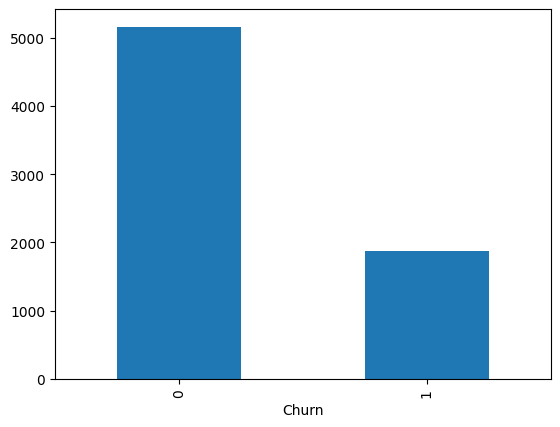

In [ ]:
df["Churn"].value_counts().plot(kind="bar")

<Axes: title={'center': 'tenure'}, xlabel='Churn'>

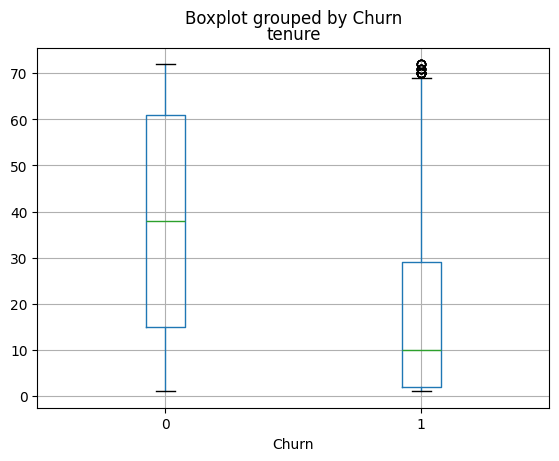

In [ ]:
df.boxplot(column="tenure", by="Churn")

In [ ]:
df.groupby("Churn")["MonthlyCharges"].mean()

,MonthlyCharges
Churn,
0,61.307408
1,74.441332


<Axes: title={'center': 'MonthlyCharges'}, xlabel='Churn'>

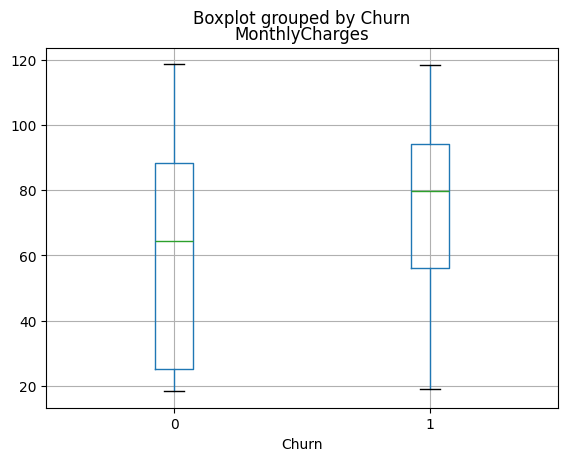

In [ ]:
df.boxplot(column="MonthlyCharges", by="Churn")

In [ ]:
df["tenure_group"] = pd.cut(df["tenure"],
                           bins=[0,12,24,48,60,100],
                           labels=["0-1yr","1-2yr","2-4yr","4-5yr","5+yr"])

In [ ]:
pd.crosstab(df["tenure_group"], df["Churn"])

Churn,0,1
tenure_group,,
0-1yr,1138,1037
1-2yr,730,294
2-4yr,1269,325
4-5yr,712,120
5+yr,1314,93


In [ ]:
pd.crosstab(df["OnlineSecurity"], df["Churn"])
pd.crosstab(df["TechSupport"], df["Churn"])

Churn,0,1
TechSupport,,
No,2026,1446
No internet service,1407,113
Yes,1730,310


In [ ]:
pd.crosstab(df["SeniorCitizen"], df["Churn"])

Churn,0,1
SeniorCitizen,,
0,4497,1393
1,666,476


In [ ]:
def churn_risk(row):
    if row["tenure"] < 12 and row["MonthlyCharges"] > 70:
        return "High Risk"
    elif row["tenure"] < 24:
        return "Medium Risk"
    else:
        return "Low Risk"

df["Risk_Level"] = df.apply(churn_risk, axis=1)

In [ ]:
df["Risk_Level"].value_counts()

,count
Risk_Level,
Low Risk,3927
Medium Risk,2281
High Risk,824


In [ ]:
df.to_csv("cleaned_churn.csv", index=False)

In [ ]:
from google.colab import files
files.download("cleaned_churn.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>